# PROJECT : ANALYSES GITHUB REPOSITORIES USING GITHUB API 

In [15]:
import requests 
import pandas as pd 
import matplotlib.pyplot as plt 

In [16]:
url = "https://api.github.com/search/repositories?q=language:python&sort=stars"

response = requests.get(url)

print(response.status_code)

200


In [17]:
data = response.json()

In [18]:
print(data.keys())

dict_keys(['total_count', 'incomplete_results', 'items'])


In [19]:
repositories = data["items"]

In [20]:
repo_list = []

for repo in repositories:

    repo_list.append({
        "Name": repo["name"],
        "Owner": repo["owner"]["login"],
        "Stars": repo["stargazers_count"],
        "Forks": repo["forks_count"],
        "Language": repo["language"],
        "Open Issues": repo["open_issues_count"]
    })

In [21]:
df = pd.DataFrame(repo_list)

df.head()

,Name,Owner,Stars,Forks,Language,Open Issues
0,public-apis,public-apis,450330,49517,Python,1533
1,free-programming-books,EbookFoundation,392175,66528,Python,72
2,system-design-primer,donnemartin,357690,57219,Python,571
3,awesome-python,vinta,308297,28319,Python,17
4,project-based-learning,practical-tutorials,273468,35264,Python,287


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Name         30 non-null     object
 1   Owner        30 non-null     object
 2   Stars        30 non-null     int64 
 3   Forks        30 non-null     int64 
 4   Language     30 non-null     object
 5   Open Issues  30 non-null     int64 
dtypes: int64(3), object(3)
memory usage: 1.5+ KB


In [23]:
df.describe()

,Stars,Forks,Open Issues
count,30.000000,30.000000,30.000000
mean,176749.866667,24526.100000,2634.166667
std,91838.859072,16200.143006,5465.603845
min,97522.000000,3956.000000,2.000000
25%,109655.500000,12009.500000,251.000000
50%,148704.000000,18508.500000,507.500000
75%,183707.750000,33044.750000,2249.250000
max,450330.000000,66528.000000,23297.000000


In [25]:
df.isnull().sum()

Name           0
Owner          0
Stars          0
Forks          0
Language       0
Open Issues    0
dtype: int64

In [27]:
df.shape

(30, 6)

In [28]:
df.duplicated().sum()

np.int64(0)

# MOST STARRED REPOSISTORIES

In [29]:
df.sort_values("Stars", ascending=False)

,Name,Owner,Stars,Forks,Language,Open Issues
0,public-apis,public-apis,450330,49517,Python,1533
1,free-programming-books,EbookFoundation,392175,66528,Python,72
2,system-design-primer,donnemartin,357690,57219,Python,571
3,awesome-python,vinta,308297,28319,Python,17
4,project-based-learning,practical-tutorials,273468,35264,Python,287
5,Python,TheAlgorithms,222712,50839,Python,1016
6,hermes-agent,NousResearch,215263,40113,Python,23297
7,AutoGPT,Significant-Gravitas,185555,46079,Python,497
8,yt-dlp,yt-dlp,178166,15237,Python,2509
9,markitdown,microsoft,166231,11904,Python,836


# Average stars 

In [30]:
df["Stars"].mean()

np.float64(176749.86666666667)

# Reposistory with the highest stars

In [ ]:
df.loc[df["Stars"].idxmax()]

# Reposistory with fewest stars

In [33]:
df.loc[df["Stars"].idxmin()]

Name           thefuck
Owner             nvbn
Stars            97522
Forks             3956
Language        Python
Open Issues        455
Name: 29, dtype: object

# Average of Forks

In [34]:
df["Forks"].mean()

np.float64(24526.1)

# Correlation 

In [35]:
df[["Stars","Forks"]].corr()

,Stars,Forks
Stars,1.000000,0.807091
Forks,0.807091,1.000000


# VISUALIZATION 

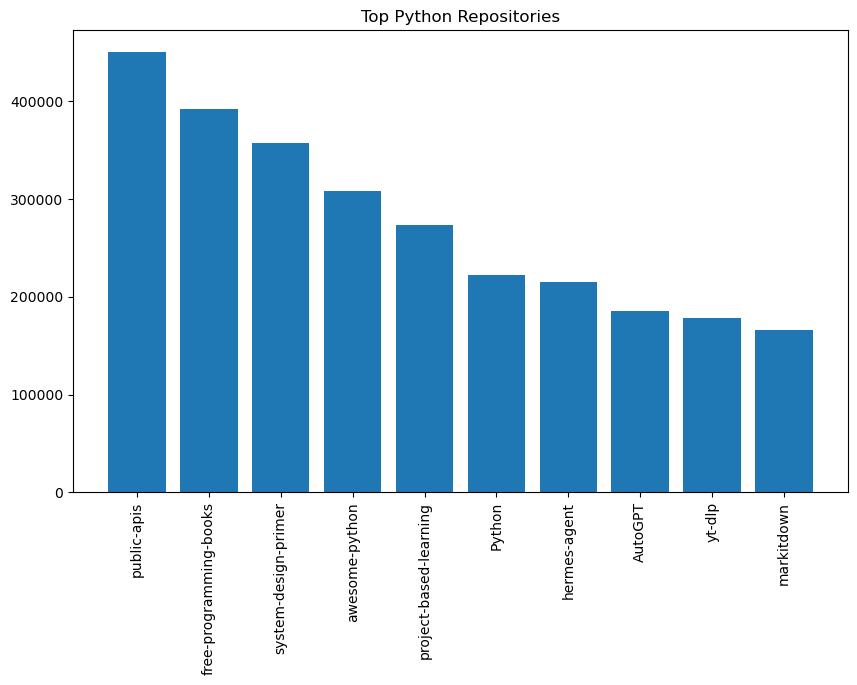

In [36]:
top10 = df.nlargest(10,"Stars")

plt.figure(figsize=(10,6))

plt.bar(top10["Name"], top10["Stars"])

plt.xticks(rotation=90)

plt.title("Top Python Repositories")

plt.show()

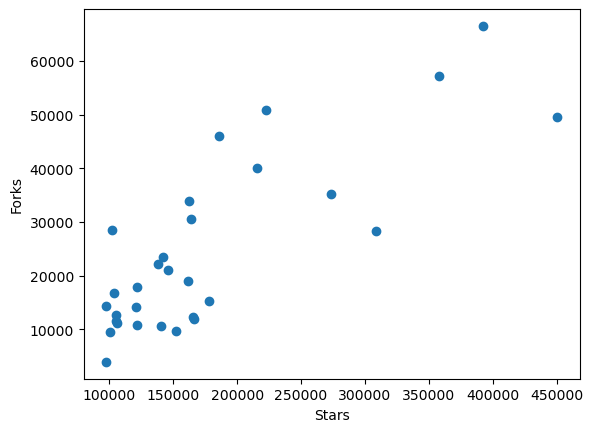

In [37]:
plt.scatter(df["Stars"], df["Forks"])

plt.xlabel("Stars")

plt.ylabel("Forks")

plt.show()